Let's check if the conductance of random lattices is similar or different. (Seed dependence)

In [39]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from tqdm import tqdm



# plotting
import matplotlib
import matplotlib.pyplot as plt

import koala.graph_utils


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
# create lattice
system_length = 30
n_seeds = 50
lattice_type = "voronoi"


# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
filling = 0.6  # filling of the lattice
theta_offset = 0  # angle of the lattice


lattices = []
for j in tqdm(range(n_seeds)):
    lattice = alter_lattice_maker(system_length, lattice_type)
    lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])
    lattice = koala.graph_utils.remove_trailing_edges(lattice)
    lattices.append(lattice)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [04:11<00:00,  5.03s/it]


/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_82753/3733624626.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  im = ax.scatter(


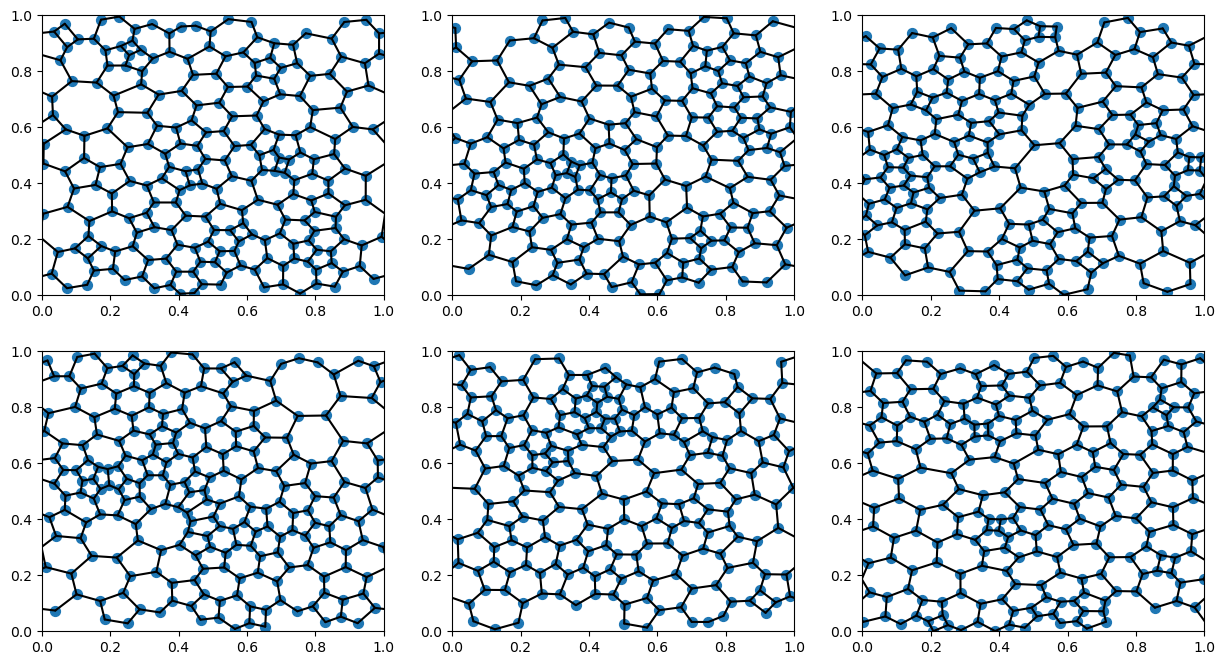

In [60]:
fig, axs = plt.subplots(2, n_seeds//2, figsize=(5*n_seeds//2, 8))
for j in range(n_seeds):
    ax = axs.flatten()[j]
    pl.plot_edges(lattices[j], ax=ax)
    im = ax.scatter(
        lattices[j].vertices.positions[:, 0],
        lattices[j].vertices.positions[:, 1],
        cmap="gist_stern_r",
        s=50,
        vmin=0,
        vmax=2,
    )

In [44]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

conds = []; ms = []; cond_spins = []; doss = []; spectrals = []

for j in tqdm(range(n_seeds)):

    lattice = lattices[j]

    hamiltonian = alt_hamiltonian(
        lattice,
        t1,
        t2,
        0,
        np.zeros(lattice.n_vertices),
    )

    energies, states = la.eigh(hamiltonian)
    fermi_energy = energies[int(filling*len(energies))] #algorithm to get Fermi energy

    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, np.diag([-1,-1,1,1])
    )

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f,energy=fermi_energy)
    g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
    
    broadening = 5e-2
    dos = np.sum(broadening/((energies-fermi_energy)**2 + broadening**2))/lattice.n_vertices/4
    

    conds.append(g[0,0]+g[1,1])
    doss.append(dos)
    

conds = np.array(conds)
doss = np.array(doss)

100%|██████████| 50/50 [30:25<00:00, 36.52s/it] 


dos: 	 0.5561011663754653  +/-  0.02042961334688173
cond: 	 4.553934393654741  +/-  0.8701496721959512


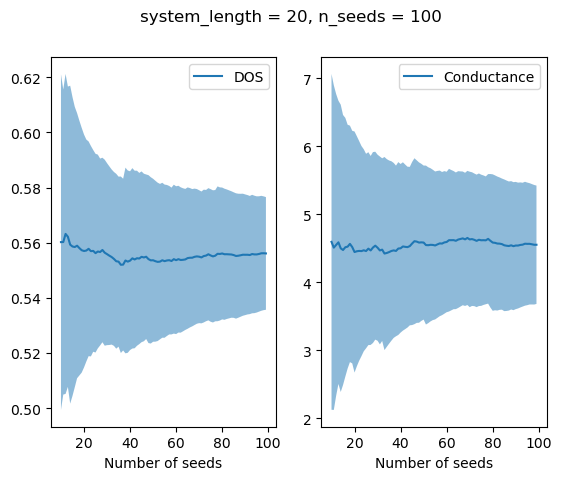

In [37]:
def cum_mean_std(array,minimal_length=1):
    cum_array = [array[:j] for j in range(minimal_length,len(array))]
    cum_mean = np.array([arr.mean() for arr in cum_array])
    cum_std = np.array([arr.std()*(len(array)/len(arr))**0.5 for arr in cum_array])
    return cum_mean,cum_std

minimal_length = 10
cond_means,cond_stds = cum_mean_std(conds,minimal_length=minimal_length)
dos_means,dos_stds = cum_mean_std(doss,minimal_length=minimal_length)

fig,axs = plt.subplots(1,2)

fig.suptitle("system_length = "+str(system_length)+", n_seeds = "+str(n_seeds))

#axs[0].plot(dos_stds)
#axs[0].errorbar(range(minimal_length,n_seeds),dos_means,yerr=dos_stds,label="DOS")
#axs[1].errorbar(range(minimal_length,n_seeds),cond_means,yerr=cond_stds,label="Conductance")

axs[0].plot(range(minimal_length,n_seeds),dos_means,label="DOS")
axs[0].fill_between(range(minimal_length,n_seeds),dos_means-dos_stds,dos_means+dos_stds,alpha=0.5)
axs[1].plot(range(minimal_length,n_seeds),cond_means,label="Conductance")
axs[1].fill_between(range(minimal_length,n_seeds),cond_means-cond_stds,cond_means+cond_stds,alpha=0.5)

axs[0].legend()
axs[1].legend()
axs[0].set_xlabel("Number of seeds")
axs[1].set_xlabel("Number of seeds")

print('dos: \t', dos_means[-1], ' +/- ', dos_stds[-1])
print('cond: \t', cond_means[-1], ' +/- ', cond_stds[-1])

dos: 	 0.5510083026378725  +/-  0.01174321604693332
cond: 	 5.149542339232914  +/-  0.8861884750117982


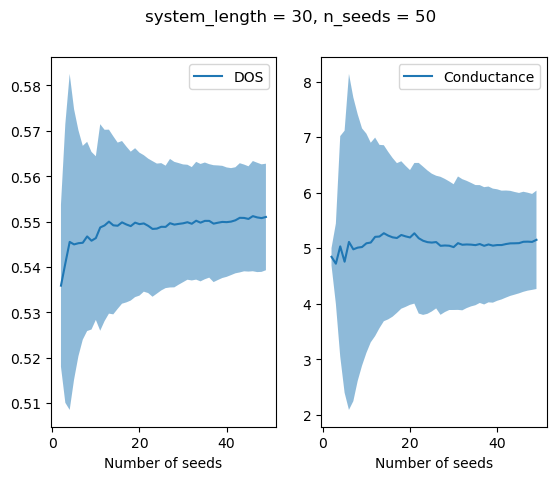

In [45]:
def cum_mean_std(array,minimal_length=1):
    cum_array = [array[:j] for j in range(minimal_length,len(array))]
    cum_mean = np.array([arr.mean() for arr in cum_array])
    cum_std = np.array([arr.std()*(len(array)/len(arr))**0.5 for arr in cum_array])
    return cum_mean,cum_std

minimal_length = 2
cond_means,cond_stds = cum_mean_std(conds,minimal_length=minimal_length)
dos_means,dos_stds = cum_mean_std(doss,minimal_length=minimal_length)

fig,axs = plt.subplots(1,2)

fig.suptitle("system_length = "+str(system_length)+", n_seeds = "+str(n_seeds))

#axs[0].plot(dos_stds)
#axs[0].errorbar(range(minimal_length,n_seeds),dos_means,yerr=dos_stds,label="DOS")
#axs[1].errorbar(range(minimal_length,n_seeds),cond_means,yerr=cond_stds,label="Conductance")

axs[0].plot(range(minimal_length,n_seeds),dos_means,label="DOS")
axs[0].fill_between(range(minimal_length,n_seeds),dos_means-dos_stds,dos_means+dos_stds,alpha=0.5)
axs[1].plot(range(minimal_length,n_seeds),cond_means,label="Conductance")
axs[1].fill_between(range(minimal_length,n_seeds),cond_means-cond_stds,cond_means+cond_stds,alpha=0.5)

axs[0].legend()
axs[1].legend()
axs[0].set_xlabel("Number of seeds")
axs[1].set_xlabel("Number of seeds")

print('dos: \t', dos_means[-1], ' +/- ', dos_stds[-1])
print('cond: \t', cond_means[-1], ' +/- ', cond_stds[-1])